In [1]:
import torch.utils.data as data
import numpy as np
import os
import sys
from PIL import Image
import torch
import random
import math
from tqdm import tqdm
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import subprocess
from collections import defaultdict

from torch.autograd import Variable
from torchinfo import summary

print(torchvision.__version__)
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.current_device())

#data_root_dir = "/scratch1/zeyut/eat_detection/"
data_root_dir = "../../results/"

0.10.0+cu111
1.9.0+cu111
True
0


In [58]:
class AverageMeter(object):
    """Computes and stores the average and current value"""

    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count
        
class GestureCountMatrix():
    def __init__(self,result_loc,gt_loc, downsample_rate, subject_wise=True):
        self.result_loc = result_loc
        self.pred_ges_loc = result_loc + "ges_boundaries/"
        self.pred_loc = result_loc + "frame_preds/"
        self.gt_loc = gt_loc
        self.downsample_rate = downsample_rate
        self.subject_wise = subject_wise
        self.video_list = [f[6:-4] for f in os.listdir(self.pred_loc) if f.startswith("preds")]

        self.subject_list = np.array([str.split(video,"_")[0] for video in self.video_list])
        self.subject_set = sorted(np.unique(self.subject_list),reverse=False)
        
    def CalculateGestureCount(self,write=False,smooth=True,smooth_kernel_params=[1,1,1,1]):
        self.CalculateBoundaries(write=write,smooth=smooth,smooth_kernel_params=smooth_kernel_params)
        
        matrixs = defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: 0)))
        for video_idx in self.video_list:
            subject = video_idx
            if self.subject_wise:
                subject = str.split(video_idx,"_")[0]
            f_gt = open(f"{self.gt_loc}{video_idx}/gt_ges_3labels.txt","r")
            gt = []
            bite_average = AverageMeter()
            drink_average = AverageMeter()

            for line in f_gt.readlines():
                info = str.split(str.split(line, "\n")[0], "\t") 
                gt.append([LABEL_TABLE[info[0]],int(info[1]),int(info[2])])
                if info[0] == "bite":
                    bite_average.update(int(info[2])-int(info[1]))
                if info[0] == "drink":
                    drink_average.update(int(info[2])-int(info[1]))
            matrixs[subject][0]["average_len"] = bite_average.avg
            matrixs[subject][1]["average_len"] = drink_average.avg

            self.evaluate_results(gt, self.predictions[video_idx], matrixs[subject])

        summary_matrixs = defaultdict(lambda: defaultdict(lambda: 0))
        if self.subject_wise:
            loop_list = self.subject_set
        else:
            loop_list = self.video_list
        for ges_type in range(2):
            for key in ['tp','fp','missed','confused']:
                for subject in loop_list:
                    summary_matrixs[ges_type][key] += matrixs[subject][ges_type][key]                           
        self.summary_matrixs = summary_matrixs
        self.matrixs = matrixs
        self.tp = [self.summary_matrixs[0]['tp'],self.summary_matrixs[1]['tp']]
        self.fp = [self.summary_matrixs[0]['fp'],self.summary_matrixs[1]['fp']]
        self.missed = [self.summary_matrixs[0]['missed'],self.summary_matrixs[1]['missed']]
        self.confused = [self.summary_matrixs[0]['confused'],self.summary_matrixs[1]['confused']]

        self.precision = [self.summary_matrixs[0]['tp']/(self.summary_matrixs[0]['tp']+self.summary_matrixs[0]['fp']),
                         self.summary_matrixs[1]['tp']/(self.summary_matrixs[1]['tp']+self.summary_matrixs[1]['fp'])]
        self.recall = [self.summary_matrixs[0]['tp']/(self.summary_matrixs[0]['tp']+self.summary_matrixs[0]['missed']),
                        self.summary_matrixs[1]['tp']/(self.summary_matrixs[1]['tp']+self.summary_matrixs[1]['missed'])]      
        self.f1 = [self.summary_matrixs[0]['tp']/(self.summary_matrixs[0]['tp']+0.5*(self.summary_matrixs[0]['fp']+self.summary_matrixs[0]['missed'])),
                  self.summary_matrixs[1]['tp']/(self.summary_matrixs[1]['tp']+0.5*(self.summary_matrixs[1]['fp']+self.summary_matrixs[1]['missed']))]
        
    def CalculateBoundaries(self, write=False,smooth=True,smooth_kernel_params=[1,1,1,1]):
        if write:
            try:
                os.mkdir(f"{self.result_loc}ges_boundaries/")
            except:
                pass
        self.predictions = {}
        for video_idx in self.video_list:
            preds, labels, start_idx = self.read_results(video_idx)
            if smooth:
                processed_preds = self.smooth_results(preds,
                                                      kernel1=smooth_kernel_params[0],
                                                      kernel2=smooth_kernel_params[1],
                                                      kernel3=smooth_kernel_params[2],
                                                      kernel4=smooth_kernel_params[3])
            else:
                processed_preds = preds
            cur_start = -1
            pred_boundaries = []
            pred_types = []
            pre_pred = -1
            for idx, pred in enumerate(processed_preds):
                if pred == pre_pred:
                    continue
                if cur_start == -1 and pred == 2:
                    continue
                if idx != 0 and cur_start != -1:
                    pred_types.append(pre_pred)
                    pred_boundaries.append([cur_start+start_idx,(idx-1)*self.downsample_rate+start_idx])
                    cur_start = -1
                else:
                    cur_start = idx * self.downsample_rate
                pre_pred = pred
            if write:
                f = open(f"{self.result_loc}ges_boundaries/ges_{video_idx}.txt","w")
                f.write("\n".join(["{}\t{}\t{}".\
                        format(ges_type,boundary[0],boundary[1]) \
                        for ges_type,boundary in (zip(pred_types,pred_boundaries))]))
                f.close()
            self.predictions[video_idx] = [[ges_type,boundary[0],boundary[1]] for ges_type,boundary in zip(pred_types,pred_boundaries)]

    def CalculateIndividualMatrix(self):
        average_precision = defaultdict(lambda: 0)
        average_recall = defaultdict(lambda: 0)
        bite_precision = defaultdict(lambda: 0) 
        bite_recall = defaultdict(lambda: 0) 
        
        if self.subject_wise:
            loop_list = self.subject_set
        else:
            loop_list = self.video_list
        for subject in loop_list:
            try:
                self.matrixs[subject][0]['precision'] = self.matrixs[subject][0]['tp']/(self.matrixs[subject][0]['tp']+self.matrixs[subject][0]['fp'])
            except:
                pass
            try:
                self.matrixs[subject][1]['precision'] = self.matrixs[subject][1]['tp']/(self.matrixs[subject][1]['tp']+self.matrixs[subject][1]['fp'])
            except:
                pass
            bite_precision[subject] = self.matrixs[subject][0]['precision']   
            # if there is a precision in "drink"
            if self.matrixs[subject][1]['tp']+self.matrixs[subject][1]['fp'] != 0:
                #average_precision[subject] = matrixs[subject][0]['precision']
                average_precision[subject] = (self.matrixs[subject][0]['precision'] + self.matrixs[subject][1]['precision']) / 2
            else:
                average_precision[subject] = self.matrixs[subject][0]['precision']

            try:
                self.matrixs[subject][0]['recall'] = self.matrixs[subject][0]['tp']/(self.matrixs[subject][0]['tp']+self.matrixs[subject][0]['missed'])
            except:
                pass
            try:
                self.matrixs[subject][1]['recall'] = self.matrixs[subject][1]['tp']/(self.matrixs[subject][1]['tp']+self.matrixs[subject][1]['missed'])
            except:
                pass
            try:
                self.matrixs[subject][0]['f1'] = self.matrixs[subject][0]['tp']/(self.matrixs[subject][0]['tp']+0.5*(self.matrixs[subject][0]['fp']+self.matrixs[subject][0]['missed']))
            except:
                pass
            try:
                self.matrixs[subject][1]['f1'] = self.matrixs[subject][1]['tp']/(self.matrixs[subject][1]['tp']+0.5*(self.matrixs[subject][1]['fp']+self.matrixs[subject][1]['missed']))
            except:
                pass
            bite_recall[subject] = self.matrixs[subject][0]['recall']   
            # if there is a recall in "drink"
            if self.matrixs[subject][1]['tp']+self.matrixs[subject][1]['missed'] != 0:
                average_recall[subject] = (self.matrixs[subject][0]['recall'] + self.matrixs[subject][1]['recall']) / 2
            else:
                average_recall[subject] = self.matrixs[subject][0]['recall']

        self.average_precision = average_precision
        self.average_recall = average_recall
        self.bite_precision = bite_precision
        self.bite_recall = bite_recall
        
        self.sorted_average_precision = {k: v for k, v in sorted(average_precision.items(), key=lambda item: item[1])}
        self.sorted_average_recall = {k: v for k, v in sorted(average_recall.items(), key=lambda item: item[1])}
        self.sorted_bite_precision = {k: v for k, v in sorted(bite_precision.items(), key=lambda item: item[1])}
        self.sorted_bite_recall = {k: v for k, v in sorted(bite_recall.items(), key=lambda item: item[1])}
        
    def PrintGlobalMatrix(self):
        print(f"=====summary=======================")
        print(f"\t\tbite\tdrink\t")
        print(f"TP\t\t{self.summary_matrixs[0]['tp']}\t{self.summary_matrixs[1]['tp']}")
        print(f"FP\t\t{self.summary_matrixs[0]['fp']}\t{self.summary_matrixs[1]['fp']}")
        print(f"Missed\t\t{self.summary_matrixs[0]['missed']}\t{self.summary_matrixs[1]['missed']}")
        print(f"Confused\t{self.summary_matrixs[0]['confused']}\t{self.summary_matrixs[1]['confused']}")
        print(f"Precision\t"
                f"{self.summary_matrixs[0]['tp']/(self.summary_matrixs[0]['tp']+self.summary_matrixs[0]['fp']):.4f}\t"
                f"{self.summary_matrixs[1]['tp']/(self.summary_matrixs[1]['tp']+self.summary_matrixs[1]['fp']):.4f}")
        print(f"Recall\t\t"
              f"{self.summary_matrixs[0]['tp']/(self.summary_matrixs[0]['tp']+self.summary_matrixs[0]['missed']):.4f}\t"
                f"{self.summary_matrixs[1]['tp']/(self.summary_matrixs[1]['tp']+self.summary_matrixs[1]['missed']):.4f}")
        print(f"F1 score\t"
              f"{self.summary_matrixs[0]['tp']/(self.summary_matrixs[0]['tp']+0.5*(self.summary_matrixs[0]['fp']+self.summary_matrixs[0]['missed'])):.4f}\t"
                f"{self.summary_matrixs[1]['tp']/(self.summary_matrixs[1]['tp']+0.5*(self.summary_matrixs[1]['fp']+self.summary_matrixs[1]['missed'])):.4f}")

    def PrintWorstIndividualMatrix(self, pivot=10):
        print(f"=====lowest {pivot} average precision=====")
        count = 0
        bad_video_list = []
        for k, v in self.sorted_bite_precision.items():
            print(f"{k}: {v:.2f}")
            bad_video_list.append(k)
            count += 1
            if count >= pivot:
                break
        print(f"=====lowest {pivot} average recall========")
        count = 0
        for k, v in self.sorted_bite_recall.items():
            print(f"{k}: {v:.2f}")
            bad_video_list.append(k)
            count += 1
            if count >= pivot:
                break
        bad_video_list = sorted(list(set(bad_video_list)))
        for subject in bad_video_list:
            print(f"====={subject}=========================")
            print(f"TP\t\t{self.matrixs[subject][0]['tp']}\t{self.matrixs[subject][1]['tp']}")
            print(f"FP\t\t{self.matrixs[subject][0]['fp']}\t{self.matrixs[subject][1]['fp']}")
            print(f"Missed\t\t{self.matrixs[subject][0]['missed']}\t{self.matrixs[subject][1]['missed']}")
            print(f"Confused\t{self.matrixs[subject][0]['confused']}\t{self.matrixs[subject][1]['confused']}")
            print(f"Precision\t"
                  f"{self.matrixs[subject][0]['precision']:.2f}\t"
                  f"{self.matrixs[subject][1]['precision']:.2f}")
            print(f"Recall\t\t"
                  f"{self.matrixs[subject][0]['recall']:.2f}\t"
                f"{self.matrixs[subject][1]['recall']:.2f}")
            print(f"average len\t"
                  f"{self.matrixs[subject][0]['average_len']:.2f}\t"
                f"{self.matrixs[subject][1]['average_len']:.2f}")

    def PrintSingleMatrix(self, subject):
        print(f"====={subject}=========================")
        print(f"TP\t\t{self.matrixs[subject][0]['tp']}\t{self.matrixs[subject][1]['tp']}")
        print(f"FP\t\t{self.matrixs[subject][0]['fp']}\t{self.matrixs[subject][1]['fp']}")
        print(f"Missed\t\t{self.matrixs[subject][0]['missed']}\t{self.matrixs[subject][1]['missed']}")
        print(f"Confused\t{self.matrixs[subject][0]['confused']}\t{self.matrixs[subject][1]['confused']}")
        print(f"Precision\t"
            f"{self.matrixs[subject][0]['precision']:.2f}\t"
            f"{self.matrixs[subject][1]['precision']:.2f}")
        print(f"Recall\t\t"
            f"{self.matrixs[subject][0]['recall']:.2f}\t"
            f"{self.matrixs[subject][1]['recall']:.2f}")
        print(f"average len\t"
            f"{self.matrixs[subject][0]['average_len']:.2f}\t"
            f"{self.matrixs[subject][1]['average_len']:.2f}")
    
    
    def smooth_results(self, results, kernel1=1,kernel2=1,kernel3=1,kernel4=1):
        #results,kernel1=4,kernel2=2,kernel3=3,kernel4=6
        #results,kernel1=8,kernel2=4,kernel3=8,kernel4=16
        """
        kernel1: for filling small gaps between bite gestures
        kernel2: for filling small gaps between drink gestures
        kernel3: for removing short bite gestures
        kernel4: for removing short drink gestures
        """
        smoothed = np.copy(results)
        for i in range(kernel1,len(results)):
            if results[i-kernel1+1] == results[i] and results[i] == 0:
                smoothed[i-kernel1+2:i] = results[i-kernel1+1]
        results = smoothed
        for i in range(kernel2,len(results)):
            if results[i-kernel2+1] == results[i] and results[i] == 1:
                smoothed[i-kernel2+2:i] = results[i-kernel2+1]
        results = smoothed
        for i in range(kernel3,len(results)):
            if results[i-kernel3+1] == results[i] and \
                results[i] == 2 and \
                0 in results[i-kernel3+2:i] and \
                1 not in results[i-kernel4+2:i]:
                smoothed[i-kernel3+2:i] = 2
        results = smoothed
        for i in range(kernel4,len(results)):
            if results[i-kernel4+1] == results[i] and \
                results[i] == 2 and \
                1 in results[i-kernel4+2:i] and \
                0 not in results[i-kernel4+2:i]:
                smoothed[i-kernel4+2:i] = 2
        return smoothed
    
    
    def read_results(self,video_idx):
        min_num = 0
        preds = []
        labels = [] 
        results = open("{}preds_{}.txt".format(self.pred_loc,video_idx),"r")
        for line in results.readlines():
            image_name = line.split("\t")[0]
            preds.append(int(line.split("\t")[2].split("\n")[0]))
            labels.append(int(line.split("\t")[1].split("\n")[0]))

            if not min_num:
                min_num = int(image_name[6:12])
        return np.array(preds),np.array(labels), min_num

    def evaluate_results(self, gt, pred, matrixs):
        #handle edge cases when gt or pred is empty
        if len(gt) == 0 and len(pred) == 0:
            return
        elif len(gt) == 0:
            matrixs[pred[0][0]]["fp"] += 1
            return self.evaluate_results(gt, pred[1:], matrixs)
        elif len(pred) == 0:
            matrixs[gt[0][0]]["missed"] += 1
            return self.evaluate_results(gt[1:], pred, matrixs)
        else:
            # read in first gesture in gt and pred, respectively
            gt_start = gt[0][1]
            gt_end = gt[0][2]
            gt_type = gt[0][0]
            pred_start = pred[0][1]
            pred_end = pred[0][2]
            pred_type = pred[0][0]
            overlap = min(pred_end-gt_start,gt_end-pred_start)  
            # the gt gesture and predicted gesture are considered matched when
            # the overlap is above 50% of either of them.
            if overlap < (gt_end-gt_start)*0.5 and \
                    overlap < (pred_end-pred_start)*0.5:
                if pred_start < gt_start:
                    matrixs[pred_type]["fp"] += 1
                    return self.evaluate_results(gt, pred[1:], matrixs)
                else:
                    matrixs[gt_type]["missed"] += 1
                    return self.evaluate_results(gt[1:], pred, matrixs)  
            else:
                if gt_type == pred_type:
                    matrixs[gt_type]["tp"] += 1
                else:
                    matrixs[gt_type]["confused"] += 1
                return self.evaluate_results(gt[1:], pred[1:], matrixs)


#### Calculate the statistical results of 2-stage models  

In [59]:
LOCAL_DETECTOR = 'X3D-S'
#LOCAL_DETECTOR = 'CNN-LSTM-S'

LABEL_TABLE = {"bite": 0, "drink": 1, "non_intake": 2}

precision_1 = []
recall_1 = []
f1_1 = []
precision_2 = []
recall_2 = []
f1_2 = []
precision_diff = []
recall_diff = []
f1_diff = []
    
for model_idx in range(1,11):
    if LOCAL_DETECTOR == 'CNN-LSTM-S':
        result_loc_1 = f"results_10runs_RES_BILSTM/{model_idx}/result_test/"
        result_loc_2 = f"/result_single_lstm_RES_BILSTM_16_2stage_all/{model_idx}/"
        downsample_rate_1 = 1
        downsample_rate_2 = 4
        fps = 8
    else:   
        result_loc_1 = f"results_10runs_X3D-S/{model_idx}/result_test/"
        result_loc_2 = f"/result_single_lstm_X3D-S_13_2stage_all/{model_idx}/"
        downsample_rate_1 = 1
        downsample_rate_2 = 2
        fps = 5        

    model_result_1 = GestureCountMatrix(result_loc = data_root_dir + result_loc_1,
                                      gt_loc = data_root_dir + f"VideoData_independent_{fps}hz/test_set/",
                                      downsample_rate = downsample_rate_1,
                                      subject_wise = False)
    
    model_result_1.CalculateGestureCount(write=True,smooth=True,smooth_kernel_params=[fps//2//downsample_rate_1,
                                                                                     fps//2//downsample_rate_1,
                                                                                     fps//2//downsample_rate_1,
                                                                                     fps//2//downsample_rate_1])
    
    
    model_result_2 = GestureCountMatrix(result_loc = data_root_dir + result_loc_2,
                                      gt_loc = data_root_dir + f"VideoData_independent_{fps}hz/test_set/",
                                      downsample_rate = downsample_rate_2,
                                      subject_wise = False)
    model_result_2.CalculateGestureCount(write=True,smooth=True,smooth_kernel_params=[fps//2//downsample_rate_2,
                                                                                     fps//2//downsample_rate_2,
                                                                                     fps//2//downsample_rate_2,
                                                                                     fps//2//downsample_rate_2])
    precision_1.append(model_result_1.precision)
    recall_1.append(model_result_1.recall)
    f1_1.append(model_result_1.f1)

    precision_2.append(model_result_2.precision)
    recall_2.append(model_result_2.recall)
    f1_2.append(model_result_2.f1)

    
    precision_diff = np.array(precision_2) - np.array(precision_1)
    recall_diff = np.array(recall_2) - np.array(recall_1)
    f1_diff = np.array(f1_2) - np.array(f1_1)

In [60]:
np.set_printoptions(precision=4)

print("LOCAL DETECTOR (bite drink)")
print(f"precision: mean: {np.mean(precision_1,axis=0)} std:{np.std(precision_1,axis=0)}")
print(f"recall: mean: {np.mean(recall_1,axis=0)} std:{np.std(recall_1,axis=0)}")
print(f"f1: mean: {np.mean(f1_1,axis=0)} std:{np.std(f1_1,axis=0)}")
print('\n')
print("GLOBAL DETECTOR (bite drink)")
print(f"precision: mean: {np.mean(precision_2,axis=0)} std:{np.std(precision_2,axis=0)}")
print(f"recall: mean: {np.mean(recall_2,axis=0)} std:{np.std(recall_2,axis=0)}")
print(f"f1: mean: {np.mean(f1_2,axis=0)} std:{np.std(f1_2,axis=0)}")


LOCAL DETECTOR (bite drink)
precision: mean: [0.8839 0.6776] std:[0.0227 0.0787]
recall: mean: [0.9287 0.8012] std:[0.0093 0.0262]
f1: mean: [0.9057 0.7322] std:[0.0153 0.0537]


GLOBAL DETECTOR (bite drink)
precision: mean: [0.9523 0.9113] std:[0.0117 0.034 ]
recall: mean: [0.9194 0.7959] std:[0.0092 0.0222]
f1: mean: [0.9355 0.8494] std:[0.0082 0.0238]


In [61]:
print("DIFFERENCE (bite drink)")
print(f"precision diff: mean: {np.mean(precision_diff,axis=0)} std:{np.std(precision_diff,axis=0)}")
print(f"recall diff: mean: {np.mean(recall_diff,axis=0)} std:{np.std(recall_diff,axis=0)}")
print(f"f1 diff: mean: {np.mean(f1_diff,axis=0)} std:{np.std(f1_diff,axis=0)}")

DIFFERENCE (bite drink)
precision diff: mean: [0.0683 0.2336] std:[0.0177 0.0522]
recall diff: mean: [-0.0093 -0.0053] std:[0.0105 0.0097]
f1 diff: mean: [0.0298 0.1172] std:[0.0125 0.0369]


### Calculate subject-wise results.

In [117]:
LABEL_TABLE = {"bite": 0, "drink": 1, "non_intake": 2}
LOCAL_DETECTOR = 'X3D-S'
#LOCAL_DETECTOR = 'CNN-LSTM-S'

model_idx = 2

if LOCAL_DETECTOR == 'CNN-LSTM-S':
    result_loc_1 = f"results_10runs_RES_BILSTM/{model_idx}/result_test/"
    result_loc_2 = f"/result_single_lstm_RES_BILSTM_16_2stage_all/{model_idx}/"
    downsample_rate_1 = 1
    downsample_rate_2 = 4
    fps = 8
else:   
    result_loc_1 = f"results_10runs_X3D-S/{model_idx}/result_test/"
    result_loc_2 = f"/result_single_lstm_X3D-S_13_2stage_all/{model_idx}/"
    downsample_rate_1 = 1
    downsample_rate_2 = 2
    fps = 5  


In [118]:
def CalculateSubjectStatistics(result_class):
    bite_len = []
    drink_len = []
    bite_precision = []
    drink_precision = []
    bite_recall = []
    drink_recall = []
    bite_f1 = []
    drink_f1 = []
    #for subject in video_list:
    for subject in result_class.subject_set:
        if result_class.matrixs[subject][0]['tp']+result_class.matrixs[subject][0]['missed'] != 0:
            bite_len.append(result_class.matrixs[subject][0]['average_len'])
            bite_precision.append(result_class.matrixs[subject][0]['precision'])
            bite_recall.append(result_class.matrixs[subject][0]['recall'])
            bite_f1.append(result_class.matrixs[subject][0]['f1'])
        if result_class.matrixs[subject][1]['tp']+result_class.matrixs[subject][1]['missed'] != 0:   
            drink_len.append(result_class.matrixs[subject][1]['average_len'])
            drink_precision.append(result_class.matrixs[subject][1]['precision'])
            drink_recall.append(result_class.matrixs[subject][1]['recall'])
            drink_f1.append(result_class.matrixs[subject][1]['f1'])   
            
    print("=====subject-wise results=========")
    print("\t\t\tbite\t\t\tdrink")
    print(f"precision:\t{np.mean(bite_precision):.4f} +/- {np.std(bite_precision):.4f}\t" \
             f"{np.mean(drink_precision):.4f} +/- {np.std(drink_precision):.4f}")
    print(f"recall:\t\t{np.mean(bite_recall):.4f} +/- {np.std(bite_recall):.4f}\t" \
             f"{np.mean(drink_recall):.4f} +/- {np.std(drink_recall):.4f}")
    print(f"f1:\t\t{np.mean(bite_f1):.4f} +/- {np.std(bite_f1):.4f}\t" \
             f"{np.mean(drink_f1):.4f} +/- {np.std(drink_f1):.4f}")    


    return  bite_len, drink_len, \
            bite_precision, drink_precision, \
            bite_recall, drink_recall, \
            bite_f1, drink_f1

In [119]:
print("LOCAL DETECTOR (one variant)")
result_class_1 = GestureCountMatrix(result_loc = data_root_dir + result_loc_1,
                                  gt_loc = data_root_dir + f"VideoData_independent_{fps}hz/test_set/",
                                  downsample_rate = downsample_rate_1,
                                  subject_wise = True)

result_class_1.CalculateGestureCount(write=False,smooth=True,smooth_kernel_params=[fps//2//downsample_rate_1,
                                                                                 fps//2//downsample_rate_1,
                                                                                 fps//2//downsample_rate_1,
                                                                                 fps//2//downsample_rate_1])
result_class_1.PrintGlobalMatrix()
result_class_1.CalculateIndividualMatrix()

print("\n")

bite_len_1, drink_len_1, bite_precision_1, drink_precision_1, \
bite_recall_1, drink_recall_1, bite_f1_1, drink_f1_1 = \
CalculateSubjectStatistics(result_class_1)


LOCAL DETECTOR (one variant)
=====summary=======================
		bite	drink	
TP		2779	454
FP		509	177
Missed		230	96
Confused	16	2
Precision	0.8452	0.7195
Recall		0.9236	0.8255
F1 score	0.8826	0.7688


=====subject-wise results=========
			bite			drink
precision:	0.8431 +/- 0.0783	0.7630 +/- 0.1752
recall:		0.9275 +/- 0.0889	0.8400 +/- 0.1814
f1:		0.8801 +/- 0.0695	0.7680 +/- 0.1283


In [120]:
print("GLOBAL DETECTOR (one local detector variant)")

result_class_2 = GestureCountMatrix(result_loc = data_root_dir + result_loc_2,
                                  gt_loc = data_root_dir + f"VideoData_independent_{fps}hz/test_set/",
                                  downsample_rate = downsample_rate_2,
                                  subject_wise = True)

result_class_2.CalculateGestureCount(write=False,smooth=True,smooth_kernel_params=[fps//2//downsample_rate_2,
                                                                                 fps//2//downsample_rate_2,
                                                                                 fps//2//downsample_rate_2,
                                                                                 fps//2//downsample_rate_2])
result_class_2.PrintGlobalMatrix()
result_class_2.CalculateIndividualMatrix()

print("\n")

bite_len_2, drink_len_2, bite_precision_2, drink_precision_2, bite_recall_2,\
drink_recall_2, bite_f1_2, drink_f1_2 = \
CalculateSubjectStatistics(result_class_2)


GLOBAL DETECTOR (one local detector variant)
=====summary=======================
		bite	drink	
TP		2759	447
FP		197	35
Missed		264	103
Confused	2	2
Precision	0.9334	0.9274
Recall		0.9127	0.8127
F1 score	0.9229	0.8663


=====subject-wise results=========
			bite			drink
precision:	0.9322 +/- 0.0527	0.9306 +/- 0.0926
recall:		0.9242 +/- 0.0951	0.8276 +/- 0.1846
f1:		0.9252 +/- 0.0627	0.8579 +/- 0.1204


### Result plots

In [121]:
import matplotlib.pyplot as plt
import matplotlib
font = {'weight' : 'normal','size': 28}

matplotlib.rc('font', **font)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

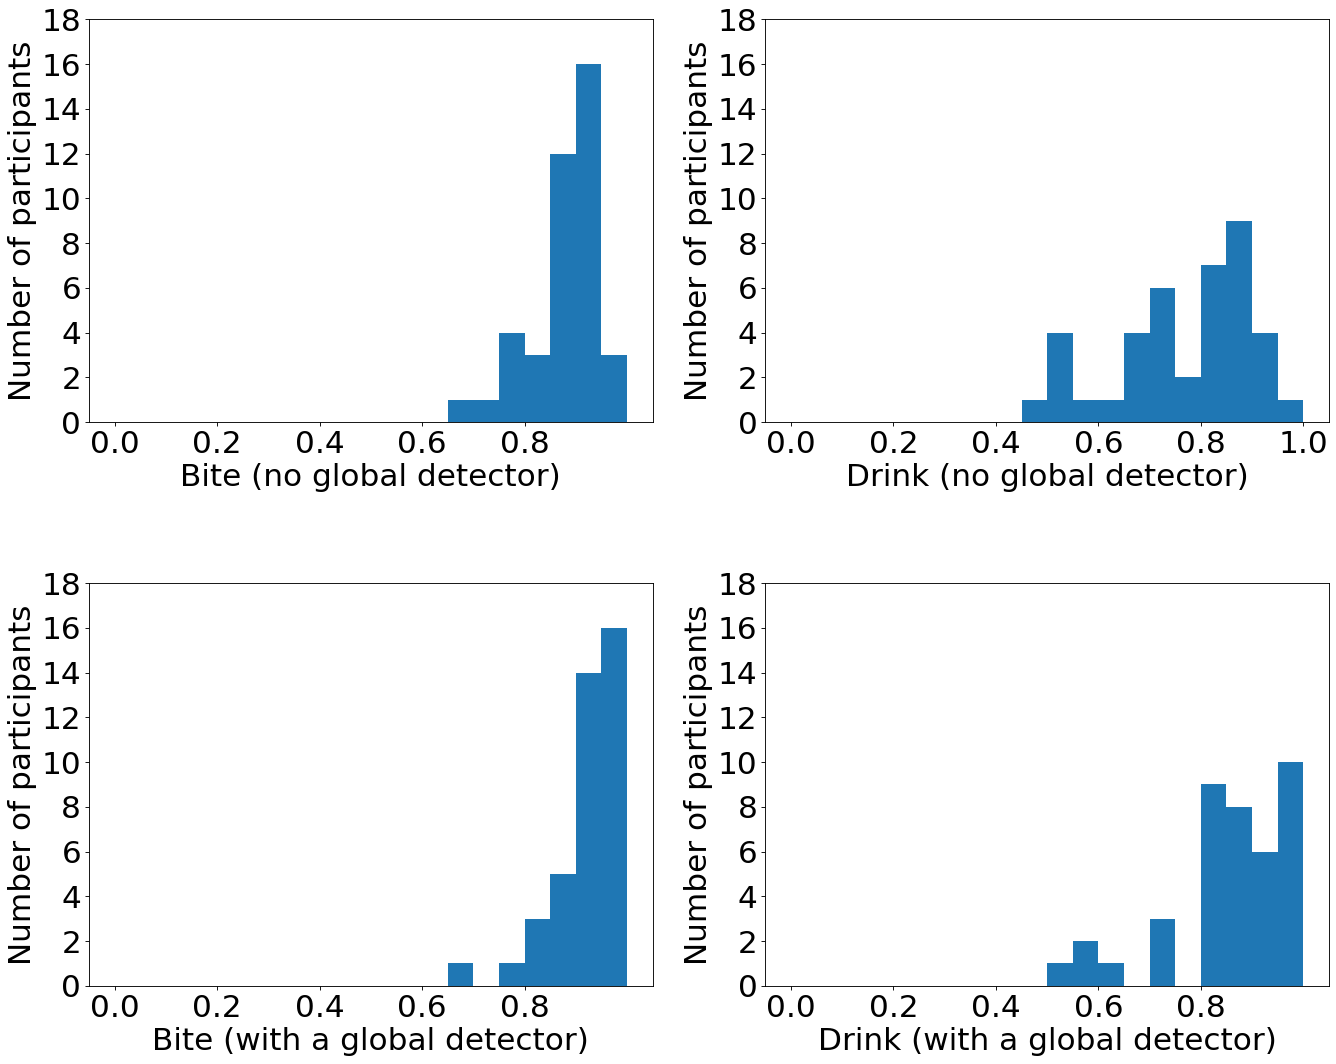

In [122]:
plt.figure(figsize=(20, 16), dpi=80)
plt.subplot(2,2,1)
plt.hist(bite_f1_1,
         bins=np.arange(0.0,1.01,0.05),
         histtype='bar')
plt.xlabel("Bite (no global detector)")
plt.ylabel("Number of participants")
plt.xticks(np.arange(.0, 1.0, 0.2))
plt.yticks(np.arange(0, 20, 2))

plt.subplot(2,2,2)
plt.hist(drink_f1_1,
         bins=np.arange(0.0,1.01,0.05),
         histtype='bar')
plt.xlabel("Drink (no global detector)")
plt.ylabel("Number of participants")
plt.xticks(np.arange(.0, 1.01, 0.2))
plt.yticks(np.arange(0, 20, 2))

plt.subplot(2,2,3)
plt.hist(bite_f1_2,
         bins=np.arange(0.0,1.01,0.05),
         histtype='bar')
plt.xlabel("Bite (with a global detector)")
plt.ylabel("Number of participants")
plt.xticks(np.arange(.0, 1.0, 0.2))
plt.yticks(np.arange(0, 20, 2))

plt.subplot(2,2,4)
plt.hist(drink_f1_2,
         bins=np.arange(0.0,1.01,0.05),
         histtype='bar')
plt.xlabel("Drink (with a global detector)")
plt.ylabel("Number of participants")
plt.xticks(np.arange(.0, 1.0, 0.2))
plt.yticks(np.arange(0, 20, 2))


plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.4)
plt.savefig("./histogram.eps",bbox_inches='tight')
#plt.show()
